In [1]:
import pandas as pd
import json as js
import numpy as np

# Reading the database, putting away it in a var "dataframe_original" and make a analysis on the dataframe

In [2]:
dataframe_original = pd.read_json("/home/felipe-rrgama/Documentos/ALURA/Pandas_limpeza_e_tratamento_de_dados/project/data/raw/original_data/dataset-telecon.json")

dataframe_original.head()

,id_cliente,Churn,cliente,telefone,internet,conta
0,0002-ORFBO,nao,"{'genero': 'feminino', 'idoso': 0, 'parceiro':...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'DSL', 'seguranca_online'...","{'contrato': None, 'faturamente_eletronico': N..."
1,0003-MKNFE,nao,"{'genero': 'masculino', 'idoso': 0, 'parceiro'...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'DSL', 'seguranca_online'...","{'contrato': 'mes a mes', 'faturamente_eletron..."
2,0004-TLHLJ,sim,"{'genero': 'masculino', 'idoso': 0, 'parceiro'...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'fibra otica', 'seguranca...","{'contrato': 'mes a mes', 'faturamente_eletron..."
3,0011-IGKFF,sim,"{'genero': 'masculino', 'idoso': 1, 'parceiro'...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'fibra otica', 'seguranca...","{'contrato': 'mes a mes', 'faturamente_eletron..."
4,0013-EXCHZ,sim,"{'genero': 'feminino', 'idoso': 1, 'parceiro':...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'fibra otica', 'seguranca...","{'contrato': 'mes a mes', 'faturamente_eletron..."


# Using the json_normalize method to normalize the dataframe

In [3]:
columns = list(dataframe_original.columns[2:6])
dfs = []

i = 0
for column in columns:
    dfs.append(pd.json_normalize(dataframe_original[column]))
    print(f'\n\n{dfs[i]}\n\n')
    i += 1



         genero  idoso parceiro dependentes  tempo_servico
0      feminino      0      sim         sim            9.0
1     masculino      0      nao         nao            9.0
2     masculino      0      nao         nao            4.0
3     masculino      1      sim         nao           13.0
4      feminino      1      sim         nao            3.0
...         ...    ...      ...         ...            ...
7339  masculino      0      sim         nao           72.0
7340  masculino      0      sim         sim           33.0
7341  masculino      1      nao         nao           32.0
7342  masculino      0      sim         sim           41.0
7343  masculino      0      nao         nao            7.0

[7344 rows x 5 columns]




     servico_telefone varias_linhas
0                 sim           nao
1                 sim           sim
2                 sim           nao
3                 sim           nao
4                 sim           nao
...               ...           ...
7339     

# Normalizando diversas colunas num dataframe com dicionários aninhados

In [4]:
with open("/home/felipe-rrgama/Documentos/ALURA/Pandas_limpeza_e_tratamento_de_dados/project/data/raw/original_data/dataset-telecon.json", 'r') as _file:
    json = js.load(_file)

In [5]:
dataframe_normalize = pd.json_normalize(json)

dataframe_normalize.head()

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0002-ORFBO,nao,feminino,0,sim,sim,9.0,sim,nao,DSL,...,sim,nao,sim,sim,nao,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,nao,masculino,0,nao,nao,9.0,sim,sim,DSL,...,nao,nao,nao,nao,sim,mes a mes,nao,cheque pelo correio,59.9,542.4
2,0004-TLHLJ,sim,masculino,0,nao,nao,4.0,sim,nao,fibra otica,...,nao,sim,nao,nao,nao,mes a mes,sim,cheque eletronico,73.9,280.85
3,0011-IGKFF,sim,masculino,1,sim,nao,13.0,sim,nao,fibra otica,...,sim,sim,nao,sim,sim,mes a mes,sim,cheque eletronico,98.0,1237.85
4,0013-EXCHZ,sim,feminino,1,sim,nao,3.0,sim,nao,fibra otica,...,nao,nao,sim,sim,nao,mes a mes,sim,cheque pelo correio,83.9,267.4


# Entendendo os dados

In [6]:
dataframe_normalize.info()

<class 'pandas.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     7344 non-null   str    
 1   Churn                          7344 non-null   str    
 2   cliente.genero                 7344 non-null   str    
 3   cliente.idoso                  7344 non-null   int64  
 4   cliente.parceiro               7344 non-null   str    
 5   cliente.dependentes            7344 non-null   str    
 6   cliente.tempo_servico          7336 non-null   float64
 7   telefone.servico_telefone      7344 non-null   str    
 8   telefone.varias_linhas         7344 non-null   str    
 9   internet.servico_internet      7344 non-null   str    
 10  internet.seguranca_online      7344 non-null   str    
 11  internet.backup_online         7344 non-null   str    
 12  internet.protecao_dispositivo  7344 non-null   str    
 13 

In [7]:
# We'll see if there is a value that contains some digits non-zero in his value

values = list(dataframe_normalize['cliente.tempo_servico'].values)

strValues = [str(value) for value in values]

def thereIsValueAfterDot(string):
    if '.' not in string:
        return False
    
    digits = string.split('.')[1]

    for char in digits:
        if char != '0':
            return True
        
    return False

soma = 0
for value in strValues:
    if thereIsValueAfterDot(value):
        print(f'The value {value} has digit(s) non-zero')
        soma += 1

print(soma)

    

0


É percepitível que há dados nulos em algumas colunas, por mais que a maioria está sem valores nulos

In [8]:
dataframe_normalize[dataframe_normalize['conta.cobranca.Total'] == ' '][
    ['cliente.tempo_servico',
    'conta.contrato',
    'conta.cobranca.mensal',
    'conta.cobranca.Total']
].info()

<class 'pandas.DataFrame'>
Index: 11 entries, 975 to 5599
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cliente.tempo_servico  11 non-null     float64
 1   conta.contrato         11 non-null     str    
 2   conta.cobranca.mensal  11 non-null     float64
 3   conta.cobranca.Total   11 non-null     str    
dtypes: float64(2), str(2)
memory usage: 440.0 bytes


In [9]:
dataframe_normalize[dataframe_normalize['conta.cobranca.Total'] == ' '][
    ['cliente.tempo_servico',
    'conta.contrato',
    'conta.cobranca.mensal',
    'conta.cobranca.Total']
]

,cliente.tempo_servico,conta.contrato,conta.cobranca.mensal,conta.cobranca.Total
975,0.0,dois anos,56.05,
1775,0.0,dois anos,20.00,
1955,0.0,dois anos,61.90,
2075,0.0,dois anos,19.70,
2232,0.0,dois anos,20.25,
2308,0.0,dois anos,25.35,
2930,0.0,dois anos,73.35,
3134,0.0,dois anos,25.75,
3203,0.0,dois anos,52.55,
4169,0.0,dois anos,80.85,


In [10]:
indexes = dataframe_normalize[dataframe_normalize['conta.cobranca.Total'] == ' '].index

In [11]:
dataframe_normalize.loc[indexes, "conta.cobranca.Total"] = (round(dataframe_normalize.loc[indexes, "conta.cobranca.mensal"] * 24, 2)).astype(str)

In [12]:
# dataframe_normalize['conta.cobranca.Total'] = dataframe_normalize['conta.cobranca.Total'].astype('float64')

dataframe_normalize.loc[indexes][
    ['cliente.tempo_servico',
    'conta.contrato',
    'conta.cobranca.mensal',
    'conta.cobranca.Total']
]

,cliente.tempo_servico,conta.contrato,conta.cobranca.mensal,conta.cobranca.Total
975,0.0,dois anos,56.05,1345.2
1775,0.0,dois anos,20.00,480.0
1955,0.0,dois anos,61.90,1485.6
2075,0.0,dois anos,19.70,472.8
2232,0.0,dois anos,20.25,486.0
2308,0.0,dois anos,25.35,608.4
2930,0.0,dois anos,73.35,1760.4
3134,0.0,dois anos,25.75,618.0
3203,0.0,dois anos,52.55,1261.2
4169,0.0,dois anos,80.85,1940.4


There are strange strings in the conta.cobranca.Total column, so we will handle them so that we can cast str to float64.

In [13]:
dataframe_normalize['conta.cobranca.Total'] = dataframe_normalize['conta.cobranca.Total'].astype('float32')

dataframe_normalize.info()

<class 'pandas.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     7344 non-null   str    
 1   Churn                          7344 non-null   str    
 2   cliente.genero                 7344 non-null   str    
 3   cliente.idoso                  7344 non-null   int64  
 4   cliente.parceiro               7344 non-null   str    
 5   cliente.dependentes            7344 non-null   str    
 6   cliente.tempo_servico          7336 non-null   float64
 7   telefone.servico_telefone      7344 non-null   str    
 8   telefone.varias_linhas         7344 non-null   str    
 9   internet.servico_internet      7344 non-null   str    
 10  internet.seguranca_online      7344 non-null   str    
 11  internet.backup_online         7344 non-null   str    
 12  internet.protecao_dispositivo  7344 non-null   str    
 13 

# Identifying and trating empty strings

In [14]:
for column in dataframe_normalize.columns:
    print(f'Coluna: {column}')
    print(dataframe_normalize[column].unique())
    print('-' * 30)

Coluna: id_cliente
<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str
------------------------------
Coluna: Churn
<StringArray>
['nao', 'sim', '']
Length: 3, dtype: str
------------------------------
Coluna: cliente.genero
<StringArray>
['feminino', 'masculino']
Length: 2, dtype: str
------------------------------
Coluna: cliente.idoso


[0 1]
------------------------------
Coluna: cliente.parceiro
<StringArray>
['sim', 'nao']
Length: 2, dtype: str
------------------------------
Coluna: cliente.dependentes
<StringArray>
['sim', 'nao']
Length: 2, dtype: str
------------------------------
Coluna: cliente.tempo_servico
[9.00e+00 4.00e+00 1.30e+01 3.00e+00 7.10e+01 6.30e+01 7.00e+00      nan
 5.40e+01 7.20e+01 5.00e+00 5.60e+01 3.40e+01 1.00e+00 4.50e+01 5.00e+01
 2.30e+01 5.50e+01 2.60e+01 6.90e+01 1.10e+01 3.70e+01 4.90e+01 6.60e+01
 6.70e+01 2.00e+01 4.30e+01 5.90e+01 1.20e+01 2.70e+01 2.00e+00 2.50e+01
 2.90e+01 1.40e+01 3.50e+01 6.40e+01 3.90e+01 4.00e+01 6.00e+00 3.00e+01
 7.00e+01 5.70e+01 5.80e+01 1.60e+01 3.20e+01 3.30e+01 1.00e+01 2.10e+01
 6.10e+01 1.50e+01 4.40e+01 2.20e+01 2.40e+01 1.90e+01 4.70e+01 6.20e+01
 4.60e+01 5.20e+01 8.00e+00 6.00e+01 4.80e+01 2.80e+01 6.50e+01 4.10e+01
 5.30e+01 6.80e+01 5.10e+01 3.10e+01 3.60e+01 1.70e+01 1.80e+01 3.80e+01
 4.20e+01 0.00e+00 1.08e+03 1.00e+03 9.50e+02 2.54e+02 3.21

In [15]:
dataframe_normalize.query("Churn == ''")

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
30,0047-ZHDTW,,feminino,0,nao,nao,11.0,sim,sim,fibra otica,...,nao,nao,nao,nao,nao,mes a mes,sim,transferencia bancaria (automatica),79.00,929.299988
75,0120-YZLQA,,masculino,0,nao,nao,71.0,sim,nao,nao,...,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,dois anos,sim,cartao de credito (automatico),19.90,1355.099976
96,0154-QYHJU,,masculino,0,nao,nao,29.0,sim,nao,DSL,...,sim,nao,sim,nao,nao,um ano,sim,cheque eletronico,58.75,1696.199951
98,0162-RZGMZ,,feminino,1,nao,nao,5.0,sim,nao,DSL,...,sim,nao,sim,nao,nao,mes a mes,nao,cartao de credito (automatico),59.90,287.850006
175,0274-VVQOQ,,masculino,1,sim,nao,65.0,sim,sim,fibra otica,...,sim,sim,nao,sim,sim,um ano,sim,transferencia bancaria (automatica),103.15,6792.450195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7211,9920-GNDMB,,masculino,0,nao,nao,9.0,sim,sim,fibra otica,...,nao,nao,nao,nao,nao,mes a mes,sim,cheque eletronico,76.25,684.849976
7239,9955-RVWSC,,feminino,0,sim,sim,67.0,sim,nao,nao,...,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,dois anos,sim,transferencia bancaria (automatica),19.25,1372.900024
7247,9966-VYRTZ,,feminino,0,sim,sim,31.0,sim,nao,nao,...,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,mes a mes,sim,cheque pelo correio,19.55,658.950012
7267,6532-YOHZY,,masculino,0,sim,sim,45.0,sim,sim,fibra otica,...,sim,sim,sim,sim,sim,dois anos,sim,transferencia bancaria (automatica),109.75,4900.649902


In [16]:
dataframe_clean = dataframe_normalize[dataframe_normalize['Churn'] != ''].copy()

In [17]:
dataframe_clean.info()

<class 'pandas.DataFrame'>
Index: 7118 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     7118 non-null   str    
 1   Churn                          7118 non-null   str    
 2   cliente.genero                 7118 non-null   str    
 3   cliente.idoso                  7118 non-null   int64  
 4   cliente.parceiro               7118 non-null   str    
 5   cliente.dependentes            7118 non-null   str    
 6   cliente.tempo_servico          7110 non-null   float64
 7   telefone.servico_telefone      7118 non-null   str    
 8   telefone.varias_linhas         7118 non-null   str    
 9   internet.servico_internet      7118 non-null   str    
 10  internet.seguranca_online      7118 non-null   str    
 11  internet.backup_online         7118 non-null   str    
 12  internet.protecao_dispositivo  7118 non-null   str    
 13  inte

In [18]:
dataframe_clean.reset_index(drop=True, inplace=True)

In [19]:
dataframe_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7118 entries, 0 to 7117
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     7118 non-null   str    
 1   Churn                          7118 non-null   str    
 2   cliente.genero                 7118 non-null   str    
 3   cliente.idoso                  7118 non-null   int64  
 4   cliente.parceiro               7118 non-null   str    
 5   cliente.dependentes            7118 non-null   str    
 6   cliente.tempo_servico          7110 non-null   float64
 7   telefone.servico_telefone      7118 non-null   str    
 8   telefone.varias_linhas         7118 non-null   str    
 9   internet.servico_internet      7118 non-null   str    
 10  internet.seguranca_online      7118 non-null   str    
 11  internet.backup_online         7118 non-null   str    
 12  internet.protecao_dispositivo  7118 non-null   str    
 13 

Verifying if there are duplicate rows and exclude that

In [20]:
print(f'Amount of duplicated rows: {dataframe_clean.duplicated().sum()}')

Amount of duplicated rows: 75


In [21]:
# There are 75 duplicated rows in the dataset, we will drop them. But, before:
filter_duplicated = dataframe_clean.duplicated()

dataframe_clean[filter_duplicated]

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
7043,0675-NCDYU,nao,feminino,0,sim,sim,72.0,sim,sim,fibra otica,...,sim,sim,sim,sim,sim,dois anos,sim,cartao de credito (automatico),116.40,8543.250000
7044,6754-LZUKA,nao,masculino,0,sim,nao,61.0,sim,sim,DSL,...,sim,sim,nao,sim,sim,dois anos,nao,transferencia bancaria (automatica),80.90,4932.500000
7045,2192-CKRLV,nao,feminino,0,sim,nao,72.0,nao,sem servico de telefone,DSL,...,sim,sim,nao,nao,sim,dois anos,sim,cheque eletronico,49.20,3580.949951
7046,9170-ARBTB,nao,feminino,0,sim,sim,52.0,sim,nao,nao,...,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,um ano,nao,cartao de credito (automatico),19.60,1012.400024
7047,0447-BEMNG,sim,feminino,0,sim,nao,48.0,nao,sem servico de telefone,DSL,...,nao,sim,nao,nao,sim,mes a mes,sim,transferencia bancaria (automatica),45.30,2145.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7113,5792-JALQC,nao,feminino,1,nao,nao,52.0,sim,sim,DSL,...,nao,sim,nao,nao,nao,dois anos,nao,transferencia bancaria (automatica),59.85,3103.250000
7114,5172-RKOCB,nao,masculino,0,sim,nao,72.0,sim,sim,fibra otica,...,sim,nao,sim,sim,sim,dois anos,sim,cartao de credito (automatico),108.95,7875.000000
7115,1934-MKPXS,nao,masculino,0,sim,sim,33.0,sim,nao,nao,...,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,um ano,nao,cartao de credito (automatico),20.10,620.549988
7116,5959-BELXA,sim,masculino,1,nao,nao,32.0,sim,sim,fibra otica,...,nao,nao,nao,sim,sim,mes a mes,sim,cartao de credito (automatico),96.15,3019.250000


### But why remove that? 
If there are duplicated row the IA model will understand that those rows is more important, giving the most attention for them. No just it, without duplicated rows, the model will have a better performance and a better results quality from the model.

In [22]:
dataframe_clean.drop_duplicates(inplace=True)

# Debugging:
print(f'Amount of duplicated rows: {dataframe_clean.duplicated().sum()}')

Amount of duplicated rows: 0


Identifying and change nulls datas

In [23]:
dataframe_clean.isna().sum() # Verifying how many null values in each column

id_cliente                        0
Churn                             0
cliente.genero                    0
cliente.idoso                     0
cliente.parceiro                  0
cliente.dependentes               0
cliente.tempo_servico             8
telefone.servico_telefone         0
telefone.varias_linhas            0
internet.servico_internet         0
internet.seguranca_online         0
internet.backup_online            0
internet.protecao_dispositivo     0
internet.suporte_tecnico          0
internet.tv_streaming             0
internet.filmes_streaming         0
conta.contrato                   31
conta.faturamente_eletronico     17
conta.metodo_pagamento           26
conta.cobranca.mensal            17
conta.cobranca.Total             15
dtype: int64

In [24]:
idxs = [] 
for i in range(len(dataframe_clean.isna().sum() + 1)):
    if dataframe_clean.isna().sum().iloc[i] != 0:
        print(f'the {i} column has null values')
        idxs.append(i)
    
print(idxs)

the 6 column has null values
the 16 column has null values
the 17 column has null values
the 18 column has null values
the 19 column has null values
the 20 column has null values
[6, 16, 17, 18, 19, 20]


In [25]:
# How many null values we have in all dataframe:
dataframe_clean.isna().sum().sum()

np.int64(114)

In [26]:
dataframe_clean[dataframe_clean.isna().any(axis=1)] #rows that have in minimium one null value

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0002-ORFBO,nao,feminino,0,sim,sim,9.0,sim,nao,DSL,...,sim,nao,sim,sim,nao,NaN,NaN,NaN,NaN,NaN
9,0016-QLJIS,nao,feminino,0,sim,sim,NaN,sim,sim,DSL,...,sim,sim,sim,sim,sim,dois anos,sim,cheque pelo correio,90.45,5957.899902
176,0282-NVSJS,nao,feminino,1,sim,sim,NaN,nao,sem servico de telefone,DSL,...,nao,nao,sim,nao,nao,mes a mes,sim,cheque pelo correio,29.30,355.899994
181,0295-QVKPB,nao,masculino,0,nao,nao,NaN,sim,nao,DSL,...,nao,sim,sim,sim,nao,mes a mes,sim,cartao de credito (automatico),63.95,318.100006
437,0639-TSIQW,sim,feminino,0,nao,nao,67.0,sim,sim,fibra otica,...,sim,sim,nao,sim,nao,NaN,NaN,cartao de credito (automatico),NaN,6886.250000
751,1095-WGNGG,nao,feminino,0,sim,nao,NaN,sim,sim,fibra otica,...,sim,nao,nao,sim,sim,dois anos,sim,transferencia bancaria (automatica),101.05,5971.250000
963,1396-QWFBJ,sim,feminino,0,sim,sim,21.0,sim,nao,fibra otica,...,sim,nao,nao,nao,nao,NaN,sim,NaN,NaN,1565.699951
1604,2333-KWEWW,nao,masculino,0,nao,nao,18.0,sim,nao,nao,...,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,sem servico de internet,NaN,nao,NaN,20.05,NaN
1605,2335-GSODA,nao,masculino,0,nao,sim,23.0,nao,sem servico de telefone,DSL,...,nao,sim,sim,nao,nao,NaN,nao,NaN,NaN,NaN
1606,2338-BQEZT,nao,feminino,0,nao,nao,55.0,sim,nao,DSL,...,nao,nao,nao,nao,nao,NaN,sim,cartao de credito (automatico),NaN,NaN


We can remove those rows or change the nulls values to non-nulls values

In [27]:
filtro = dataframe_clean['cliente.tempo_servico'].isna()

In [28]:
dataframe_clean[filtro][[
    'cliente.tempo_servico',
    'conta.cobranca.mensal',
    'conta.cobranca.Total'
]]

,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
9,NaN,90.45,5957.899902
176,NaN,29.30,355.899994
181,NaN,63.95,318.100006
751,NaN,101.05,5971.250000
3523,NaN,76.10,1054.800049
5273,NaN,20.60,116.599998
5276,NaN,73.85,3581.399902
6134,NaN,69.05,1958.449951


In [29]:
dataframe_clean['cliente.tempo_servico'] = dataframe_clean['cliente.tempo_servico'].fillna(
    np.ceil(
        dataframe_clean['conta.cobranca.Total'] / dataframe_clean['conta.cobranca.mensal']
    ), inplace=True
)

/tmp/ipykernel_5487/1132053634.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataframe_clean['cliente.tempo_servico'] = dataframe_clean['cliente.tempo_servico'].fillna(


In [30]:
dataframe_clean.isna().sum()

id_cliente                        0
Churn                             0
cliente.genero                    0
cliente.idoso                     0
cliente.parceiro                  0
cliente.dependentes               0
cliente.tempo_servico             0
telefone.servico_telefone         0
telefone.varias_linhas            0
internet.servico_internet         0
internet.seguranca_online         0
internet.backup_online            0
internet.protecao_dispositivo     0
internet.suporte_tecnico          0
internet.tv_streaming             0
internet.filmes_streaming         0
conta.contrato                   31
conta.faturamente_eletronico     17
conta.metodo_pagamento           26
conta.cobranca.mensal            17
conta.cobranca.Total             15
dtype: int64

Removing the null datas

In [31]:
dataframe_clean.isnull().sum()

id_cliente                        0
Churn                             0
cliente.genero                    0
cliente.idoso                     0
cliente.parceiro                  0
cliente.dependentes               0
cliente.tempo_servico             0
telefone.servico_telefone         0
telefone.varias_linhas            0
internet.servico_internet         0
internet.seguranca_online         0
internet.backup_online            0
internet.protecao_dispositivo     0
internet.suporte_tecnico          0
internet.tv_streaming             0
internet.filmes_streaming         0
conta.contrato                   31
conta.faturamente_eletronico     17
conta.metodo_pagamento           26
conta.cobranca.mensal            17
conta.cobranca.Total             15
dtype: int64

In [32]:
dataframe_clean['conta.contrato'].value_counts()

conta.contrato
mes a mes    3861
dois anos    1688
um ano       1463
Name: count, dtype: int64

In [33]:
columns_drop = ['conta.contrato', 'conta.faturamente_eletronico', 'conta.metodo_pagamento']

In [34]:
dataframe_clean[columns_drop].isnull().any(axis=1).sum() # Amount of null rows in those 3 columns

np.int64(37)

In [35]:
# Removing those 37 null values
dataframe_nonnulls = dataframe_clean.dropna(subset=columns_drop).copy()

In [36]:
dataframe_nonnulls.reset_index(drop=True, inplace=True)

In [37]:
dataframe_nonnulls

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0003-MKNFE,nao,masculino,0,nao,nao,9.0,sim,sim,DSL,...,nao,nao,nao,nao,sim,mes a mes,nao,cheque pelo correio,59.90,542.400024
1,0004-TLHLJ,sim,masculino,0,nao,nao,4.0,sim,nao,fibra otica,...,nao,sim,nao,nao,nao,mes a mes,sim,cheque eletronico,73.90,280.850006
2,0011-IGKFF,sim,masculino,1,sim,nao,13.0,sim,nao,fibra otica,...,sim,sim,nao,sim,sim,mes a mes,sim,cheque eletronico,98.00,1237.849976
3,0013-EXCHZ,sim,feminino,1,sim,nao,3.0,sim,nao,fibra otica,...,nao,nao,sim,sim,nao,mes a mes,sim,cheque pelo correio,83.90,267.399994
4,0013-MHZWF,nao,feminino,0,nao,sim,9.0,sim,nao,DSL,...,nao,nao,sim,sim,sim,mes a mes,sim,cartao de credito (automatico),69.40,571.450012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7001,9987-LUTYD,nao,feminino,0,nao,nao,13.0,sim,nao,DSL,...,nao,nao,sim,nao,nao,um ano,nao,cheque pelo correio,55.15,742.900024
7002,9992-RRAMN,sim,masculino,0,sim,nao,22.0,sim,sim,fibra otica,...,nao,nao,nao,nao,sim,mes a mes,sim,cheque eletronico,85.10,1873.699951
7003,9992-UJOEL,nao,masculino,0,nao,nao,2.0,sim,nao,DSL,...,sim,nao,nao,nao,nao,mes a mes,sim,cheque pelo correio,50.30,92.750000
7004,9993-LHIEB,nao,masculino,0,sim,sim,67.0,sim,nao,DSL,...,nao,sim,sim,nao,sim,dois anos,nao,cheque pelo correio,67.85,4627.649902


In [38]:
dataframe_nonnulls.isnull().sum()

id_cliente                       0
Churn                            0
cliente.genero                   0
cliente.idoso                    0
cliente.parceiro                 0
cliente.dependentes              0
cliente.tempo_servico            0
telefone.servico_telefone        0
telefone.varias_linhas           0
internet.servico_internet        0
internet.seguranca_online        0
internet.backup_online           0
internet.protecao_dispositivo    0
internet.suporte_tecnico         0
internet.tv_streaming            0
internet.filmes_streaming        0
conta.contrato                   0
conta.faturamente_eletronico     0
conta.metodo_pagamento           0
conta.cobranca.mensal            0
conta.cobranca.Total             0
dtype: int64

### Working with outliers

In [39]:
# We have to identify if there is outliers in our dataset.
dataframe_nonnulls.describe() # this method describe everything there is in a box-plot

,cliente.idoso,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
count,7006.000000,7006.000000,7006.000000,7006.000000
mean,0.162004,33.248501,64.720361,2317.743896
std,0.368481,35.333897,30.084664,2876.918945
min,0.000000,0.000000,18.250000,18.799999
25%,0.000000,9.000000,35.450000,402.087509
50%,0.000000,29.000000,70.300000,1392.924988
75%,0.000000,56.000000,89.850000,3783.599976
max,1.000000,1080.000000,118.750000,112212.000000


In [40]:
import seaborn as sn

<Axes: xlabel='cliente.tempo_servico'>

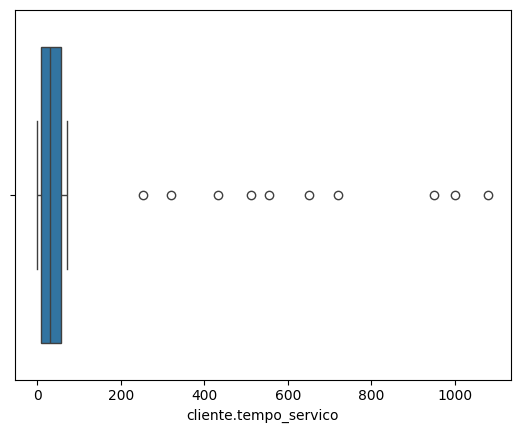

In [41]:
# Using the boxplot to identify the outliers in the dataser
sn.boxplot(
    x=dataframe_nonnulls['cliente.tempo_servico']
)

In [42]:
# Now, we know that there are outliers, but dont know which values are those.
Q1 = dataframe_nonnulls['cliente.tempo_servico'].quantile(0.25)
Q3 = dataframe_nonnulls['cliente.tempo_servico'].quantile(0.75)
IQR = Q3- Q1 # IQR is the interquartile range, that is the distance between the first and third quartiles
limit_inf = Q1 - 1.5 * IQR
limit_sup = Q3 + 1.5 * IQR

In [43]:
# Making the filter to outliers:
outliers_index = (dataframe_nonnulls['cliente.tempo_servico'] < limit_inf) | (dataframe_nonnulls['cliente.tempo_servico'] > limit_sup)

In [44]:
dataframe_nonnulls[outliers_index]['cliente.tempo_servico'] # here we got the outliers values

1945    1080.0
1946    1000.0
1952     950.0
1956     254.0
1958     321.0
1963     650.0
1966     721.0
1970     555.0
1973     433.0
1974     512.0
Name: cliente.tempo_servico, dtype: float64

In [45]:
# Now, we have to decide what to do with those outliers. We'll change the outliers by a correctly values.
dataframe_without_outliers = dataframe_nonnulls.copy()

In [46]:
dataframe_without_outliers.loc[outliers_index, 'cliente.tempo_servico'] = np.ceil(dataframe_without_outliers.loc[outliers_index, 'conta.cobranca.Total'] / dataframe_without_outliers.loc[outliers_index, 'conta.cobranca.mensal'])

dataframe_without_outliers[outliers_index]['cliente.tempo_servico']

1945    1080.0
1946    1000.0
1952     951.0
1956       2.0
1958      43.0
1963     650.0
1966      44.0
1970       7.0
1973       4.0
1974       1.0
Name: cliente.tempo_servico, dtype: float64

<Axes: xlabel='cliente.tempo_servico'>

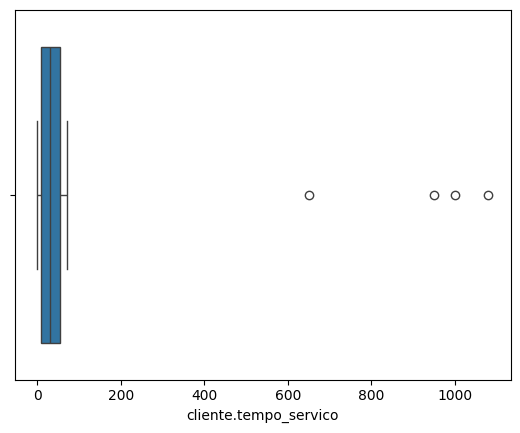

In [47]:
sn.boxplot(x=dataframe_without_outliers['cliente.tempo_servico'])

In [48]:
dataframe_without_outliers[outliers_index][['cliente.tempo_servico', 'conta.cobranca.Total', 'conta.cobranca.mensal']]

,cliente.tempo_servico,conta.cobranca.Total,conta.cobranca.mensal
1945,1080.0,112212.000000,103.90
1946,1000.0,45900.000000,45.90
1952,951.0,79895.000000,84.10
1956,2.0,80.349998,46.05
1958,43.0,4259.299805,99.80
1963,650.0,47450.000000,73.00
1966,44.0,3856.750000,89.55
1970,7.0,124.400002,19.15
1973,4.0,346.200012,89.20
1974,1.0,19.549999,19.55


In [ ]:
outliers_index = (dataframe_without_outliers['cliente.tempo_servico'] < limit_inf) | (dataframe_without_outliers['cliente.tempo_servico'] > limit_sup)

In [50]:
dataframe_without_outliers[outliers_index][[
    'cliente.tempo_servico', 
    'conta.cobranca.Total', 
    'conta.cobranca.mensal'  
]]

,cliente.tempo_servico,conta.cobranca.Total,conta.cobranca.mensal
1945,1080.0,112212.0,103.9
1946,1000.0,45900.0,45.9
1952,951.0,79895.0,84.1
1963,650.0,47450.0,73.0


### Removing outliers

In [54]:
dataframe_without_outliers = dataframe_without_outliers[~outliers_index] # o tio serve como uma negação

dataframe_without_outliers.reset_index(inplace=True, drop=True)

/tmp/ipykernel_5487/263285709.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dataframe_without_outliers = dataframe_without_outliers[~outliers_index] # o tio serve como uma negação


In [55]:
dataframe_without_outliers

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0003-MKNFE,nao,masculino,0,nao,nao,9.0,sim,sim,DSL,...,nao,nao,nao,nao,sim,mes a mes,nao,cheque pelo correio,59.90,542.400024
1,0004-TLHLJ,sim,masculino,0,nao,nao,4.0,sim,nao,fibra otica,...,nao,sim,nao,nao,nao,mes a mes,sim,cheque eletronico,73.90,280.850006
2,0011-IGKFF,sim,masculino,1,sim,nao,13.0,sim,nao,fibra otica,...,sim,sim,nao,sim,sim,mes a mes,sim,cheque eletronico,98.00,1237.849976
3,0013-EXCHZ,sim,feminino,1,sim,nao,3.0,sim,nao,fibra otica,...,nao,nao,sim,sim,nao,mes a mes,sim,cheque pelo correio,83.90,267.399994
4,0013-MHZWF,nao,feminino,0,nao,sim,9.0,sim,nao,DSL,...,nao,nao,sim,sim,sim,mes a mes,sim,cartao de credito (automatico),69.40,571.450012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997,9987-LUTYD,nao,feminino,0,nao,nao,13.0,sim,nao,DSL,...,nao,nao,sim,nao,nao,um ano,nao,cheque pelo correio,55.15,742.900024
6998,9992-RRAMN,sim,masculino,0,sim,nao,22.0,sim,sim,fibra otica,...,nao,nao,nao,nao,sim,mes a mes,sim,cheque eletronico,85.10,1873.699951
6999,9992-UJOEL,nao,masculino,0,nao,nao,2.0,sim,nao,DSL,...,sim,nao,nao,nao,nao,mes a mes,sim,cheque pelo correio,50.30,92.750000
7000,9993-LHIEB,nao,masculino,0,sim,sim,67.0,sim,nao,DSL,...,nao,sim,sim,nao,sim,dois anos,nao,cheque pelo correio,67.85,4627.649902


<Axes: xlabel='cliente.tempo_servico'>

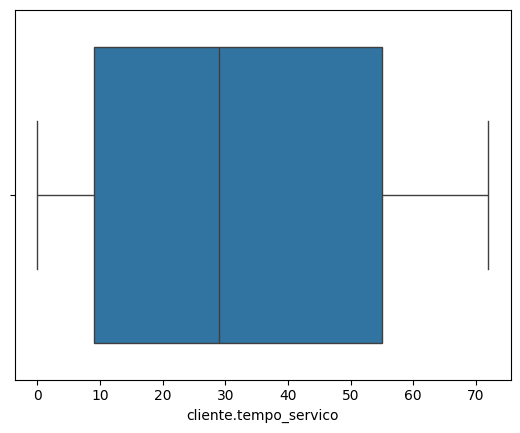

In [56]:
sn.boxplot(x=dataframe_without_outliers['cliente.tempo_servico'])